# 00 — Common base (reference)
The preamble below is the **single source of truth**. Copy it verbatim into 01 and 02. Drive holds **only** the dataset zip.

In [11]:
# --- Setup (run each session) ---
!pip -q install PyWavelets scikit-image numpy scipy matplotlib pandas pillow

In [12]:
# ================= COMMON PREAMBLE (identical in 00/01/02) =================
# Drive holds ONLY the dataset zip. Each notebook is self-contained:
# mount -> unzip -> load/split -> define Forward, metrics, degrade_det.
from google.colab import drive
drive.mount("/content/drive")

import os, glob, zipfile, numpy as np
from PIL import Image
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.metrics import peak_signal_noise_ratio as _psnr, structural_similarity as _ssim

# ---- EDIT only these ----
DRIVE = "/content/drive/MyDrive/GroupF"
ZIP   = f"{DRIVE}/retina_dataset.zip"
DATA  = "/content/data"                 # ephemeral VM disk

# ---- shared params ----
ANGLE, KSIZE = 45, 9
NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]
IMG_SIZE, SUBSET, SEED = 256, 4000, 42

# ---- unzip once per session ----
if not os.path.exists(DATA):
    os.makedirs(DATA, exist_ok=True)
    with zipfile.ZipFile(ZIP) as z: z.extractall(DATA)

# ---- forward model ----
def motion_blur_kernel(size=KSIZE, angle=ANGLE):
    k=np.zeros((size,size)); c=(size-1)/2; th=np.deg2rad(angle)
    dx,dy=np.cos(th),np.sin(th)
    for t in np.linspace(-c,c,size*4):
        x=int(round(c+t*dx)); y=int(round(c+t*dy))
        if 0<=x<size and 0<=y<size: k[y,x]=1.0
    return k/k.sum()
def _fft_psf(psf,shape):
    H,W=shape; kh,kw=psf.shape
    pf=np.zeros((H,W)); pf[:kh,:kw]=psf
    pf=np.roll(pf,(-(kh//2),-(kw//2)),axis=(0,1)); return np.fft.fft2(pf)
class Forward:
    def __init__(self, shape, ksize=KSIZE, angle=ANGLE):
        self.psf=motion_blur_kernel(ksize,angle); self.F=_fft_psf(self.psf,shape)
    def A(self,x):  return np.real(np.fft.ifft2(np.fft.fft2(x)*self.F))
    def AT(self,x): return np.real(np.fft.ifft2(np.fft.fft2(x)*np.conj(self.F)))

def psnr(g,p): return float(_psnr(g,p,data_range=1.0))
def ssim(g,p): return float(_ssim(g,p,data_range=1.0))

# ---- dataset loader ----
EXT=("*.png","*.jpg","*.jpeg","*.tif","*.tiff","*.bmp")
def list_images(root):
    p=[]
    for e in EXT: p+=glob.glob(os.path.join(root,"**",e), recursive=True)
    return sorted(p)
def preprocess_file(path):
    img=np.asarray(Image.open(path))
    if img.ndim==3: img=rgb2gray(img)
    img=resize(img,(IMG_SIZE,IMG_SIZE),anti_aliasing=True)
    return ((img-img.min())/(img.max()-img.min()+1e-12)).astype(np.float32)
def load_dataset(root, subset=SUBSET, seed=SEED):
    paths=list_images(root)
    rng=np.random.default_rng(seed); rng.shuffle(paths); paths=paths[:subset]
    return np.stack([preprocess_file(p) for p in paths])
def split_data(X, seed=SEED, tr=0.8, va=0.1):
    n=len(X); idx=np.random.default_rng(seed).permutation(n)
    a,b=int(n*tr),int(n*(tr+va)); return X[idx[:a]],X[idx[a:b]],X[idx[b:]]

# ---- DETERMINISTIC degradation: identical inputs for all methods ----
def degrade_det(fw, x, sigma, idx):
    rng=np.random.default_rng(SEED*100003+int(idx))
    return np.clip(fw.A(x)+rng.normal(0,sigma,x.shape),0,1)

# ---- build dataset (in memory; nothing extra written to Drive) ----
print("images found:", len(list_images(DATA)))
X = load_dataset(DATA, subset=SUBSET)
Xtr, Xva, Xte = split_data(X)
print("loaded", X.shape, "| train/val/test:", len(Xtr), len(Xva), len(Xte))
# ============================ END PREAMBLE ============================

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
images found: 4162
loaded (4000, 256, 256) | train/val/test: 3200 400 400


### Self-test

PSNR 30.41 SSIM 0.827 | reproducible: True


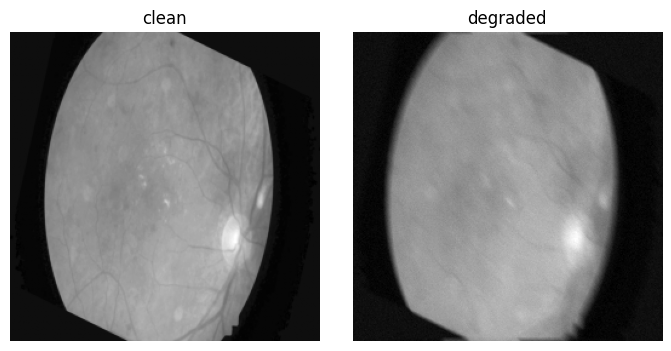

In [13]:
import matplotlib.pyplot as plt
fw=Forward((IMG_SIZE,IMG_SIZE)); x=Xte[0]; y=degrade_det(fw,x,0.01,idx=0)
print("PSNR",round(psnr(x,y),2),"SSIM",round(ssim(x,y),3),
      "| reproducible:", np.allclose(degrade_det(fw,x,0.01,0),degrade_det(fw,x,0.01,0)))
fig,ax=plt.subplots(1,2,figsize=(7,3.5))
ax[0].imshow(x,cmap="gray");ax[0].set_title("clean");ax[0].axis("off")
ax[1].imshow(y,cmap="gray");ax[1].set_title("degraded");ax[1].axis("off")
plt.tight_layout();plt.show()